In [15]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [18]:
patient_col = "subject_id"
target_col = "alsfrs_r_total"

week5_model_path = repo_root / "data" / "processed" / "alsfrs_modeling_week5.csv"

modeling_df = pd.read_csv(week5_model_path)
modeling_df.head(), modeling_df.shape

(   subject_id  alsfrs_delta  visit_number  baseline_alsfrs_r_total  \
 0        3301          40.0             2                     35.0   
 1        3301          98.0             3                     35.0   
 2        3301         161.0             4                     35.0   
 3        3301         221.0             5                     35.0   
 4        3301         273.0             6                     35.0   
 
    prev_alsfrs_r_total  time_since_first_visit  delta_from_prev_visit  age  \
 0                 35.0                    35.0                   35.0  NaN   
 1                 34.0                    93.0                   58.0  NaN   
 2                 32.0                   156.0                   63.0  NaN   
 3                 32.0                   216.0                   60.0  NaN   
 4                 34.0                   268.0                   52.0  NaN   
 
     sex  onset_delta site_of_onset  alsfrs_r_total  
 0  Male      -1049.0   Onset: Limb       

In [19]:
print("Rows:", len(modeling_df))
print("Unique patients:", modeling_df[patient_col].nunique())
print("Columns:")
print(list(modeling_df.columns))

Rows: 45841
Unique patients: 5704
Columns:
['subject_id', 'alsfrs_delta', 'visit_number', 'baseline_alsfrs_r_total', 'prev_alsfrs_r_total', 'time_since_first_visit', 'delta_from_prev_visit', 'age', 'sex', 'onset_delta', 'site_of_onset', 'alsfrs_r_total']


In [20]:
missing_summary = (
    modeling_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
)

missing_summary.columns = ["column", "missing_fraction"]
missing_summary.head(20)

,column,missing_fraction
0,site_of_onset,0.326694
1,age,0.121812
2,onset_delta,0.033813
3,subject_id,0.000000
4,alsfrs_delta,0.000000
5,visit_number,0.000000
6,baseline_alsfrs_r_total,0.000000
7,prev_alsfrs_r_total,0.000000
8,time_since_first_visit,0.000000
9,delta_from_prev_visit,0.000000


In [21]:
feature_cols = [
    col for col in modeling_df.columns
    if col not in [patient_col, target_col]
]

print("Feature columns:")
print(feature_cols)

Feature columns:
['alsfrs_delta', 'visit_number', 'baseline_alsfrs_r_total', 'prev_alsfrs_r_total', 'time_since_first_visit', 'delta_from_prev_visit', 'age', 'sex', 'onset_delta', 'site_of_onset']


In [22]:
patients = modeling_df[patient_col].dropna().unique()

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42
)

train_df = modeling_df[modeling_df[patient_col].isin(train_patients)].copy()
test_df = modeling_df[modeling_df[patient_col].isin(test_patients)].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train patients:", train_df[patient_col].nunique())
print("Test patients:", test_df[patient_col].nunique())

Train rows: 36623
Test rows: 9218
Train patients: 4563
Test patients: 1141


In [23]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

In [24]:
naive_pred = test_df["prev_alsfrs_r_total"]

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = rmse_score(y_test, naive_pred)
naive_r2 = r2_score(y_test, naive_pred)

print("Naive baseline MAE:", round(naive_mae, 4))
print("Naive baseline RMSE:", round(naive_rmse, 4))
print("Naive baseline R^2:", round(naive_r2, 4))

Naive baseline MAE: 1.9398
Naive baseline RMSE: 3.0123
Naive baseline R^2: 0.8822


In [25]:
numeric_features = []
categorical_features = []

for col in feature_cols:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['alsfrs_delta', 'visit_number', 'baseline_alsfrs_r_total', 'prev_alsfrs_r_total', 'time_since_first_visit', 'delta_from_prev_visit', 'age', 'onset_delta']
Categorical features: ['sex', 'site_of_onset']


In [26]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [27]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = rmse_score(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression MAE:", round(linear_mae, 4))
print("Linear Regression RMSE:", round(linear_rmse, 4))
print("Linear Regression R^2:", round(linear_r2, 4))

Linear Regression MAE: 1.8298
Linear Regression RMSE: 2.6188
Linear Regression R^2: 0.9109


In [29]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = rmse_score(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", round(rf_mae, 4))
print("Random Forest RMSE:", round(rf_rmse, 4))
print("Random Forest R^2:", round(rf_r2, 4))

Random Forest MAE: 1.8218
Random Forest RMSE: 2.5995
Random Forest R^2: 0.9122


In [30]:
gbr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gbr_model.fit(X_train, y_train)
gbr_pred = gbr_model.predict(X_test)

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = rmse_score(y_test, gbr_pred)
gbr_r2 = r2_score(y_test, gbr_pred)

print("Gradient Boosting MAE:", round(gbr_mae, 4))
print("Gradient Boosting RMSE:", round(gbr_rmse, 4))
print("Gradient Boosting R^2:", round(gbr_r2, 4))

Gradient Boosting MAE: 1.8058
Gradient Boosting RMSE: 2.5736
Gradient Boosting R^2: 0.914


In [31]:
metrics_df = pd.DataFrame([
    {
        "model_name": "naive_previous_visit",
        "mae": naive_mae,
        "rmse": naive_rmse,
        "r2": naive_r2,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_patients": train_df[patient_col].nunique(),
        "n_test_patients": test_df[patient_col].nunique()
    },
    {
        "model_name": "linear_regression",
        "mae": linear_mae,
        "rmse": linear_rmse,
        "r2": linear_r2,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_patients": train_df[patient_col].nunique(),
        "n_test_patients": test_df[patient_col].nunique()
    },
    {
        "model_name": "random_forest",
        "mae": rf_mae,
        "rmse": rf_rmse,
        "r2": rf_r2,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_patients": train_df[patient_col].nunique(),
        "n_test_patients": test_df[patient_col].nunique()
    },
    {
        "model_name": "gradient_boosting",
        "mae": gbr_mae,
        "rmse": gbr_rmse,
        "r2": gbr_r2,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_patients": train_df[patient_col].nunique(),
        "n_test_patients": test_df[patient_col].nunique()
    }
])

metrics_df.sort_values("rmse")

,model_name,mae,rmse,r2,n_train_rows,n_test_rows,n_train_patients,n_test_patients
3,gradient_boosting,1.805794,2.573580,0.913980,36623,9218,4563,1141
2,random_forest,1.821809,2.599467,0.912241,36623,9218,4563,1141
1,linear_regression,1.829816,2.618816,0.910929,36623,9218,4563,1141
0,naive_previous_visit,1.939792,3.012288,0.882153,36623,9218,4563,1141


In [32]:
week6_metrics_path = repo_root / "reports" / "week6_model_comparison_metrics.csv"
metrics_df.to_csv(week6_metrics_path, index=False)

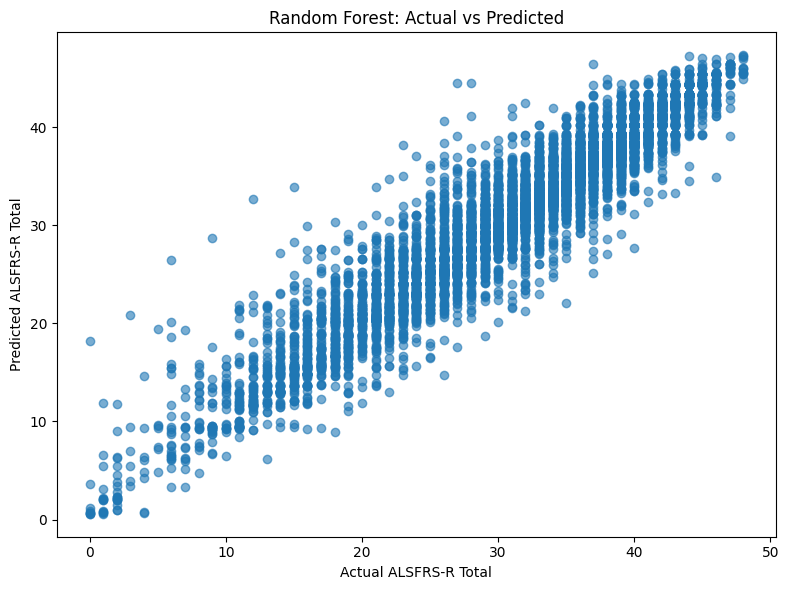

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.xlabel("Actual ALSFRS-R Total")
plt.ylabel("Predicted ALSFRS-R Total")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.savefig(repo_root / "figures" / "week6_actual_vs_predicted_rf.png", dpi=300)
plt.show()

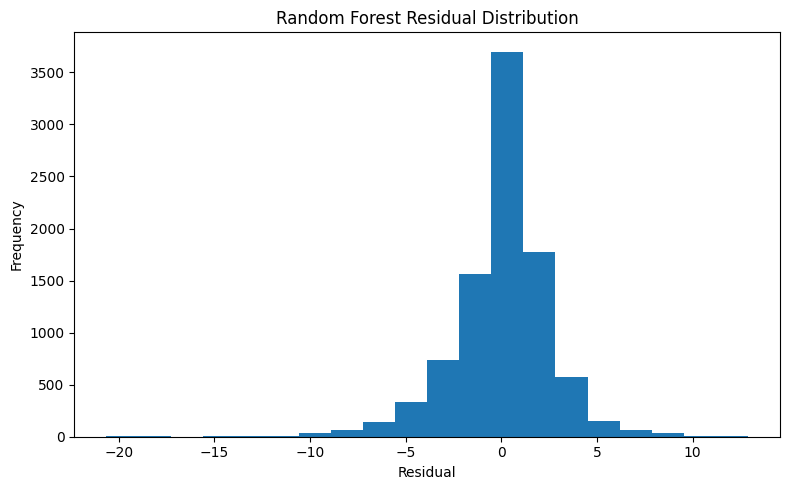

In [34]:
rf_residuals = y_test - rf_pred

plt.figure(figsize=(8, 5))
plt.hist(rf_residuals, bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Random Forest Residual Distribution")
plt.tight_layout()
plt.savefig(repo_root / "figures" / "week6_residuals_rf.png", dpi=300)
plt.show()

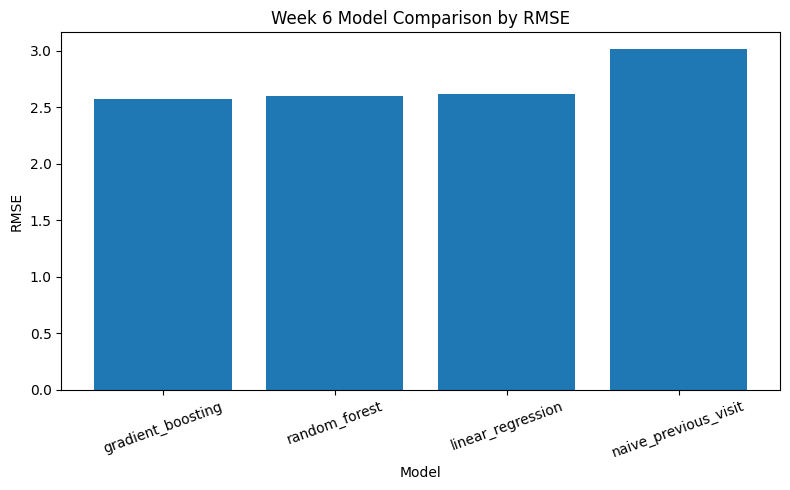

In [35]:
plot_df = metrics_df.sort_values("rmse").copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model_name"], plot_df["rmse"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Week 6 Model Comparison by RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(repo_root / "figures" / "week6_model_metric_comparison.png", dpi=300)
plt.show()

In [36]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_estimator = rf_model.named_steps["model"]

encoded_feature_names = rf_preprocessor.get_feature_names_out()
feature_importance_df = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": rf_estimator.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
3,num__prev_alsfrs_r_total,0.977097
5,num__delta_from_prev_visit,0.013455
7,num__onset_delta,0.003403
2,num__baseline_alsfrs_r_total,0.001911
6,num__age,0.001227
0,num__alsfrs_delta,0.000918
4,num__time_since_first_visit,0.000870
1,num__visit_number,0.000585
10,cat__site_of_onset_Onset: Bulbar,0.000124
11,cat__site_of_onset_Onset: Limb,0.000090


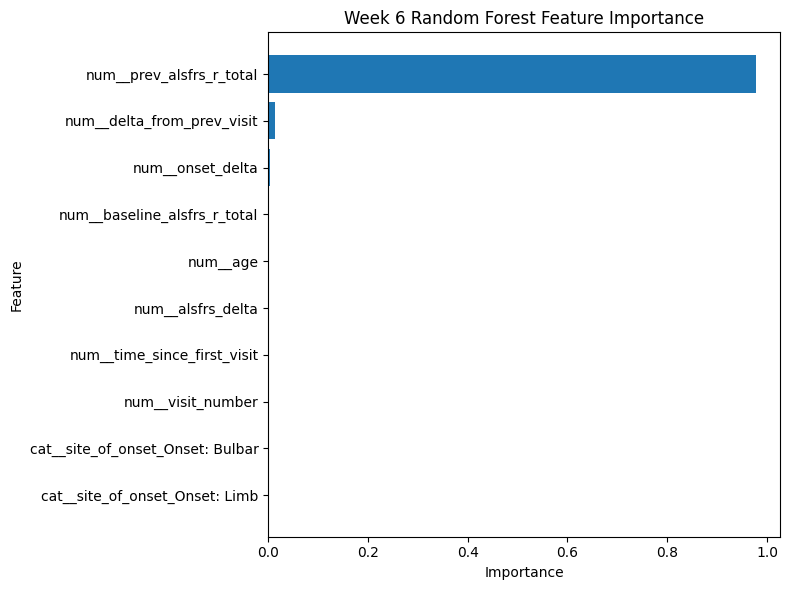

In [37]:
top_features = feature_importance_df.head(10).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Week 6 Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(repo_root / "figures" / "week6_feature_importance_rf.png", dpi=300)
plt.show()

In [38]:
feature_importance_path = repo_root / "reports" / "week6_rf_feature_importance.csv"
feature_importance_df.to_csv(feature_importance_path, index=False)